In [54]:
import pandas as pd

In [200]:
# 223428010210 陈梓欣
#表头为用户ID，购买日期，购买数量，购买金额
columns=['user_id','order_dt','order_products','order_amount']
df = pd.read_csv('CDNOW_master.txt', names=columns, sep='\\s+')

In [201]:
# 223428010210 陈梓欣
# 观察数据
print(df)

       user_id  order_dt  order_products  order_amount
0            1  19970101               1         11.77
1            2  19970112               1         12.00
2            2  19970112               5         77.00
3            3  19970102               2         20.76
4            3  19970330               2         20.76
...        ...       ...             ...           ...
69654    23568  19970405               4         83.74
69655    23568  19970422               1         14.99
69656    23569  19970325               2         25.74
69657    23570  19970325               3         51.12
69658    23570  19970326               2         42.96

[69659 rows x 4 columns]


In [202]:
# 223428010210 陈梓欣
# 观察数据（前几行）
print(df.head())

   user_id  order_dt  order_products  order_amount
0        1  19970101               1         11.77
1        2  19970112               1         12.00
2        2  19970112               5         77.00
3        3  19970102               2         20.76
4        3  19970330               2         20.76


In [197]:
# 223428010210 陈梓欣
# 查看数据的前五行
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69659 entries, 0 to 69658
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         69659 non-null  int64         
 1   order_dt        69659 non-null  datetime64[ns]
 2   order_products  69659 non-null  int64         
 3   order_amount    69659 non-null  float64       
 4   month           69659 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(2)
memory usage: 2.7 MB
None


In [198]:
# 223428010103 刘渤
# 查看数据的数据类型
print(df.dtypes)

user_id                    int64
order_dt          datetime64[ns]
order_products             int64
order_amount             float64
month             datetime64[ns]
dtype: object


In [199]:
# 223428010103 刘渤
# 数据中是否存在缺失值
print(df.isnull().sum())

user_id           0
order_dt          0
order_products    0
order_amount      0
month             0
dtype: int64


In [203]:
# 223428010103 刘渤
# 查看数据的统计描述
print(df.describe())

            user_id      order_dt  order_products  order_amount
count  69659.000000  6.965900e+04    69659.000000  69659.000000
mean   11470.854592  1.997228e+07        2.410040     35.893648
std     6819.904848  3.837735e+03        2.333924     36.281942
min        1.000000  1.997010e+07        1.000000      0.000000
25%     5506.000000  1.997022e+07        1.000000     14.490000
50%    11410.000000  1.997042e+07        2.000000     25.980000
75%    17273.000000  1.997111e+07        3.000000     43.700000
max    23570.000000  1.998063e+07       99.000000   1286.010000


In [204]:
# 223428010103 刘渤
# 时间数据类型转换
df['order_dt']=pd.to_datetime(df['order_dt'],format='%Y%m%d')
print(df.head())

   user_id   order_dt  order_products  order_amount
0        1 1997-01-01               1         11.77
1        2 1997-01-12               1         12.00
2        2 1997-01-12               5         77.00
3        3 1997-01-02               2         20.76
4        3 1997-03-30               2         20.76


In [205]:
# 223428010103 刘渤
# 查看数据的统计描述
print(df.describe())

            user_id                       order_dt  order_products  \
count  69659.000000                          69659    69659.000000   
mean   11470.854592  1997-07-02 22:36:51.401254656        2.410040   
min        1.000000            1997-01-01 00:00:00        1.000000   
25%     5506.000000            1997-02-22 00:00:00        1.000000   
50%    11410.000000            1997-04-24 00:00:00        2.000000   
75%    17273.000000            1997-11-07 00:00:00        3.000000   
max    23570.000000            1998-06-30 00:00:00       99.000000   
std     6819.904848                            NaN        2.333924   

       order_amount  
count  69659.000000  
mean      35.893648  
min        0.000000  
25%       14.490000  
50%       25.980000  
75%       43.700000  
max     1286.010000  
std       36.281942  


In [206]:
# 223428010103 刘渤
# 计算所有用户购买商品的平均数量
avg_quantity = df['order_products'].mean()
print("avg_quantity: ", avg_quantity)

avg_quantity:  2.41004033936749


In [207]:
# 223428010103 刘渤
# 计算所有用户购买商品的平均花费
avg_amount = df['order_amount'].mean()
print("avg_amount：", avg_amount)

avg_amount： 35.89364805696321


In [208]:
# 223428010103 刘渤
# 在源数据中添加一列表示月份，默认是每月的第1天
df['month'] = df.order_dt.values.astype('datetime64[M]')
print(df.head())

   user_id   order_dt  order_products  order_amount      month
0        1 1997-01-01               1         11.77 1997-01-01
1        2 1997-01-12               1         12.00 1997-01-01
2        2 1997-01-12               5         77.00 1997-01-01
3        3 1997-01-02               2         20.76 1997-01-01
4        3 1997-03-30               2         20.76 1997-03-01


In [73]:
# 223428010210 陈梓欣
# 每月的总销售额
ze=df['order_amount'].groupby(df['month']).sum()
print(ze)

month
1997-01-01    299060.17
1997-02-01    379590.03
1997-03-01    393155.27
1997-04-01    142824.49
1997-05-01    107933.30
1997-06-01    108395.87
1997-07-01    122078.88
1997-08-01     88367.69
1997-09-01     81948.80
1997-10-01     89780.77
1997-11-01    115448.64
1997-12-01     95577.35
1998-01-01     76756.78
1998-02-01     77096.96
1998-03-01    108970.15
1998-04-01     66231.52
1998-05-01     70989.66
1998-06-01     76109.30
Name: order_amount, dtype: float64


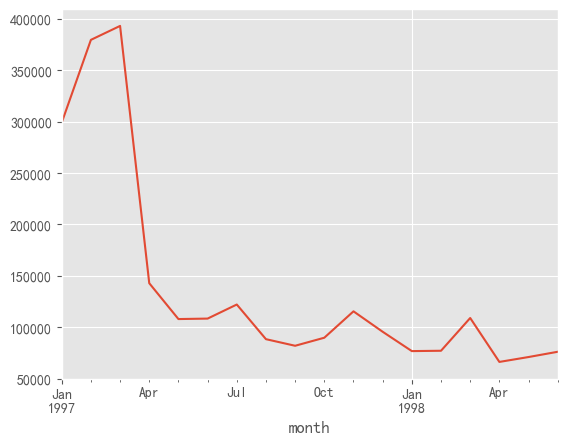

In [74]:
# 223428010210 陈梓欣
# 绘制折线图
import matplotlib.pyplot as plt   #加载可视化包
plt.style.use('ggplot')    #更改设计风格

ze.plot()
plt.show()

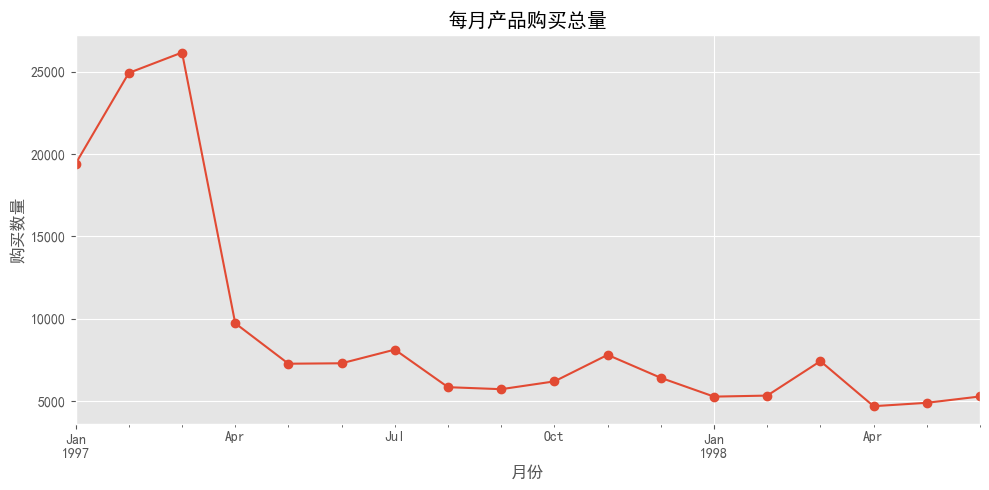

In [75]:
# 223428010210 陈梓欣
# 所有用户每月的产品购买量
monthly_products = df['order_products'].groupby(df['month']).sum()

# 绘图
monthly_products.plot(title='每月产品购买总量', figsize=(10, 5), marker='o')
plt.xlabel('月份')
plt.ylabel('购买数量')
plt.grid(True)
plt.tight_layout()
plt.show()

In [76]:
# 223428010210 陈梓欣
# 每月消费的总金额
monthly_amount = df['order_amount'].groupby(df['month']).sum()
print(monthly_amount)

month
1997-01-01    299060.17
1997-02-01    379590.03
1997-03-01    393155.27
1997-04-01    142824.49
1997-05-01    107933.30
1997-06-01    108395.87
1997-07-01    122078.88
1997-08-01     88367.69
1997-09-01     81948.80
1997-10-01     89780.77
1997-11-01    115448.64
1997-12-01     95577.35
1998-01-01     76756.78
1998-02-01     77096.96
1998-03-01    108970.15
1998-04-01     66231.52
1998-05-01     70989.66
1998-06-01     76109.30
Name: order_amount, dtype: float64


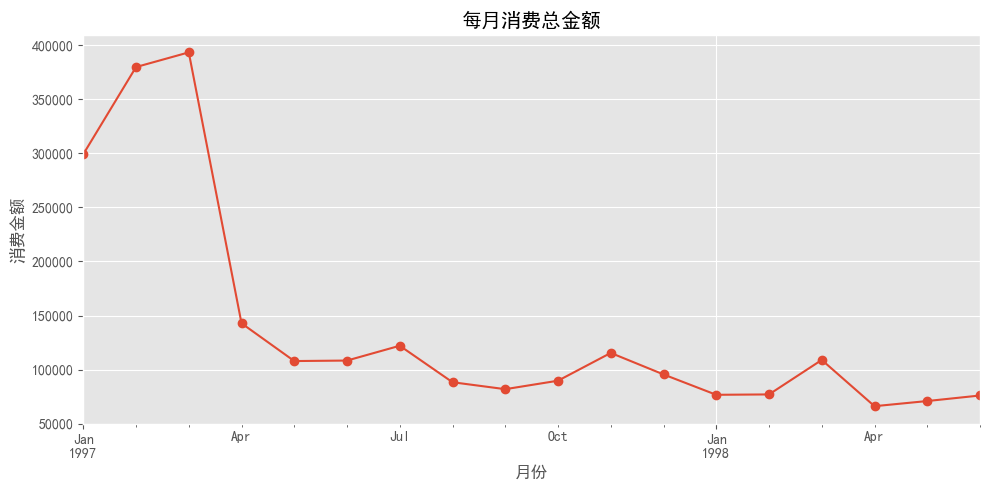

In [77]:
#223428010210 陈梓欣
import matplotlib.pyplot as plt

# 绘制每月消费金额变化趋势图
monthly_amount.plot(title='每月消费总金额', figsize=(10, 5), marker='o')
plt.xlabel('月份')
plt.ylabel('消费金额')
plt.grid(True)
plt.tight_layout()
plt.show()

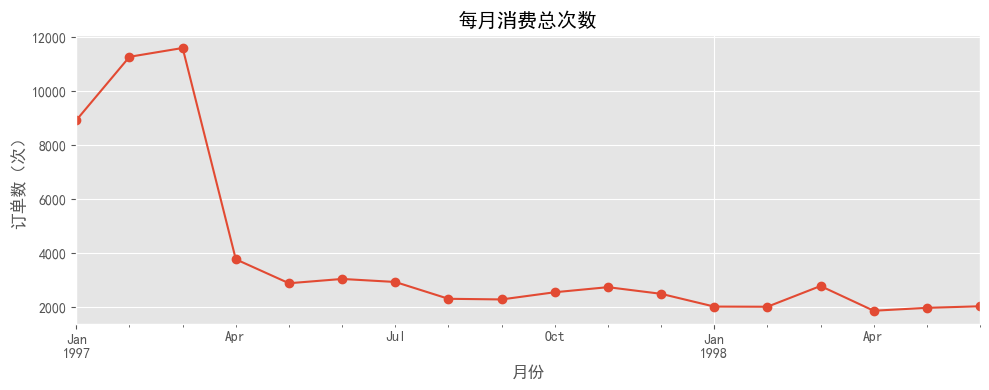

In [79]:
# 223428010210 陈梓欣
# 每月消费总次数
monthly_transaction_count = df.groupby('month').size()

# 折线图：每月消费总次数
monthly_transaction_count.plot(title='每月消费总次数', figsize=(10, 4), marker='o')
plt.xlabel('月份')
plt.ylabel('订单数（次）')
plt.grid(True)
plt.tight_layout()
plt.show()

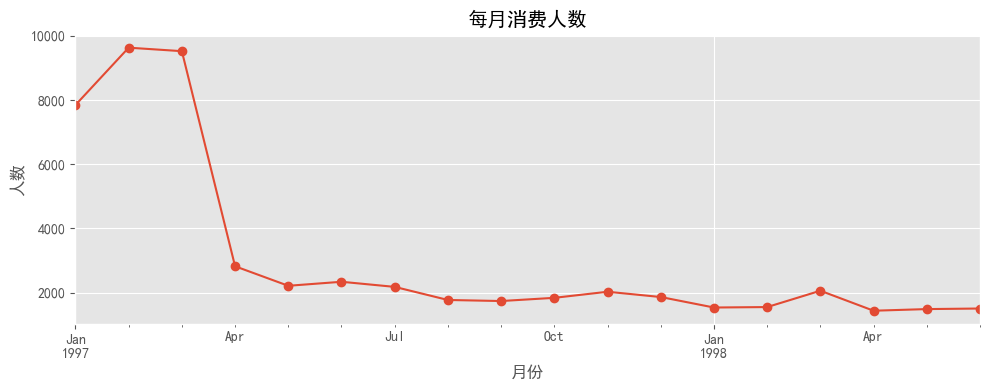

In [83]:
# 223428010210 陈梓欣
# 每月消费人数
monthly_unique_users = df.groupby('month')['user_id'].nunique()

# 折线图：每月消费人数
monthly_unique_users.plot(title='每月消费人数', figsize=(10, 4), marker='o')
plt.xlabel('月份')
plt.ylabel('人数')
plt.grid(True)
plt.tight_layout()
plt.show()

In [85]:
# 223428010210 陈梓欣
# 用户维度聚合：每人一行
user_group = df.groupby('user_id').agg({
    'order_amount': 'sum',
    'order_products': 'sum',
    'order_dt': 'count'  # 用于消费总次数
}).rename(columns={'order_dt': 'order_count'})

print(user_group)

         order_amount  order_products  order_count
user_id                                           
1               11.77               1            1
2               89.00               6            2
3              156.46              16            6
4              100.50               7            4
5              385.61              29           11
...               ...             ...          ...
23566           36.00               2            1
23567           20.97               1            1
23568          121.70               6            3
23569           25.74               2            1
23570           94.08               5            2

[23570 rows x 3 columns]


In [86]:
# 223428010210 陈梓欣
# 消费金额和消费次数的统计描述
print("用户消费总金额描述：")
print(user_group['order_amount'].describe())

print("\n用户消费总次数描述：")
print(user_group['order_count'].describe())

用户消费总金额描述：
count    23570.000000
mean       106.080426
std        240.925195
min          0.000000
25%         19.970000
50%         43.395000
75%        106.475000
max      13990.930000
Name: order_amount, dtype: float64

用户消费总次数描述：
count    23570.000000
mean         2.955409
std          4.736558
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        217.000000
Name: order_count, dtype: float64


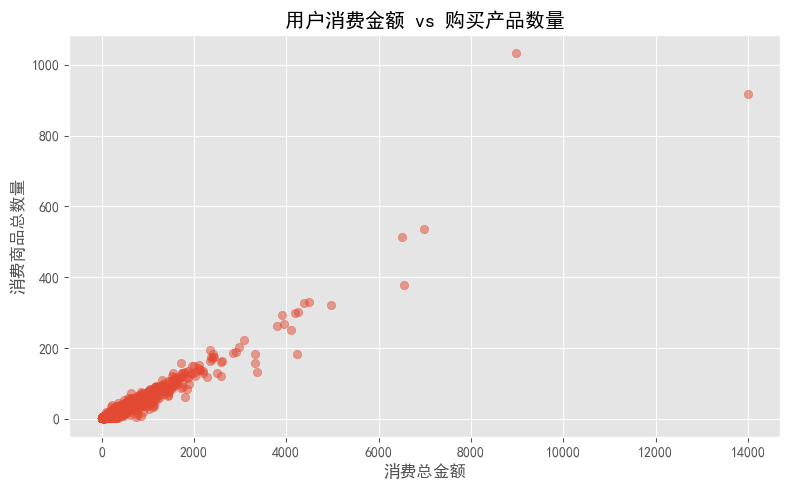

In [89]:
# 223428010210 陈梓欣
# 用户消费金额和消费产品数量的散点图

plt.figure(figsize=(8, 5))
plt.scatter(user_group['order_amount'], user_group['order_products'], alpha=0.5)
plt.title('用户消费金额 vs 购买产品数量')
plt.xlabel('消费总金额')
plt.ylabel('消费商品总数量')
plt.grid(True)
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

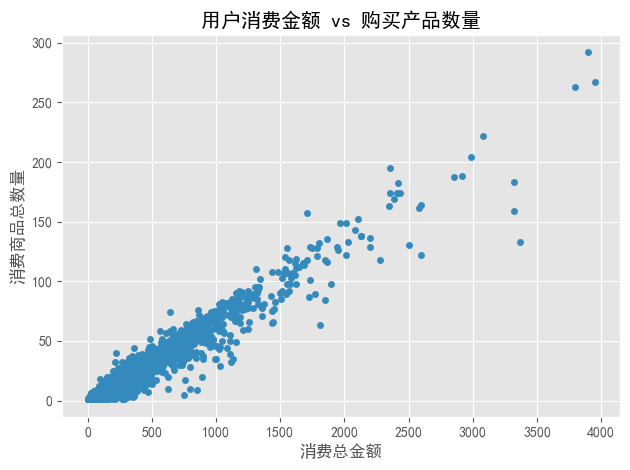

In [92]:
# 223428010210 陈梓欣
# 用户消费金额和消费产品数量的散点图

plt.figure(figsize=(8, 5))
user_group.query('order_amount<4000').plot.scatter(x='order_amount',y='order_products')
plt.title('用户消费金额 vs 购买产品数量')
plt.xlabel('消费总金额')
plt.ylabel('消费商品总数量')
plt.grid(True)
plt.tight_layout()
plt.show()

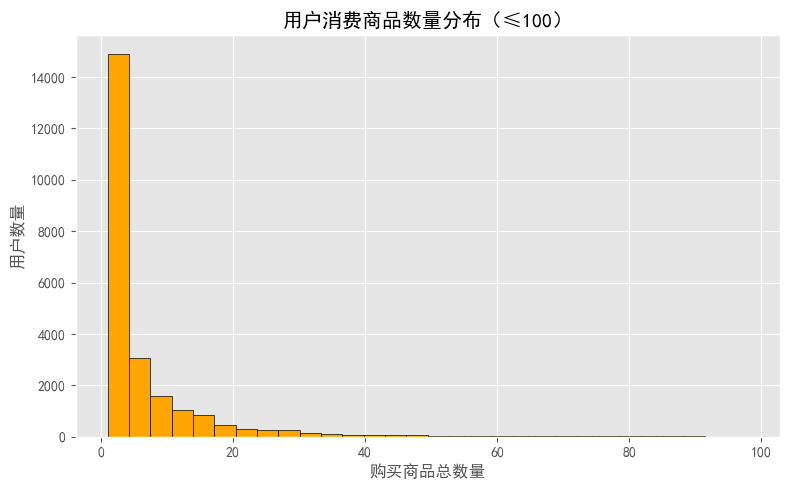

In [102]:
# 223428010210 陈梓欣
# 筛选出消费数量 ≤ 100 的用户
products_within_100 = user_group[user_group['order_products'] <= 100]

plt.figure(figsize=(8, 5))
plt.hist(products_within_100['order_products'], bins=30, color='orange', edgecolor='black')
plt.title('用户消费商品数量分布（≤100）')
plt.xlabel('购买商品总数量')
plt.ylabel('用户数量')
plt.grid(True)
plt.tight_layout()
plt.show()

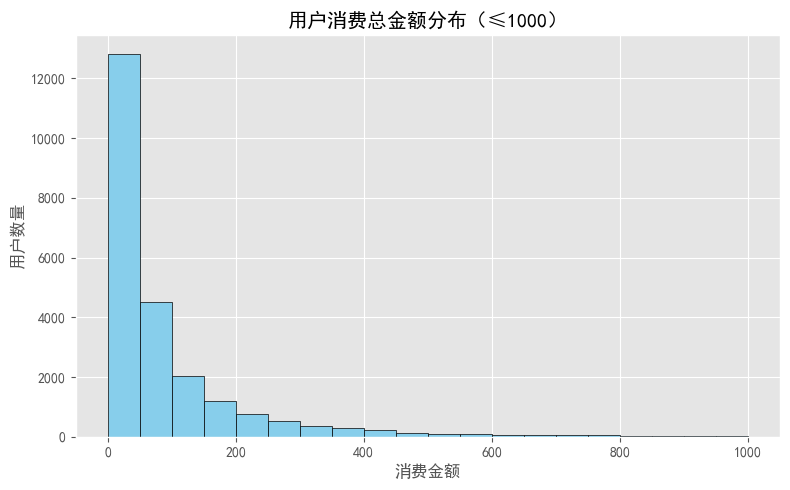

In [103]:
# 223428010210 陈梓欣
# 筛选出消费金额 ≤ 1000 的用户
amount_within_1000 = user_group[user_group['order_amount'] <= 1000]

plt.figure(figsize=(8, 5))
plt.hist(amount_within_1000['order_amount'], bins=20, color='skyblue', edgecolor='black')
plt.title('用户消费总金额分布（≤1000）')
plt.xlabel('消费金额')
plt.ylabel('用户数量')
plt.grid(True)
plt.tight_layout()
plt.show()

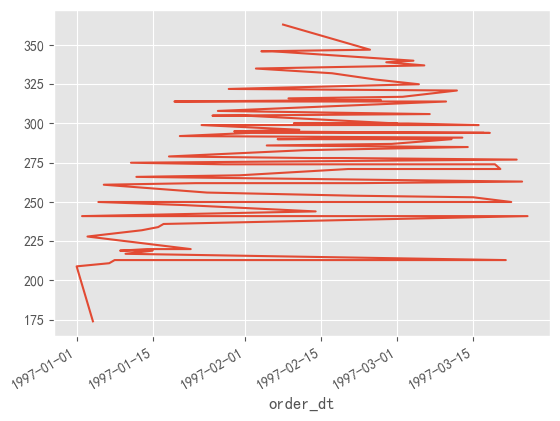

In [111]:
# 223428010210 陈梓欣
# 获取每个用户的首次消费时间
df['order_dt'].groupby(df['user_id']).min().value_counts().plot()
plt.show()


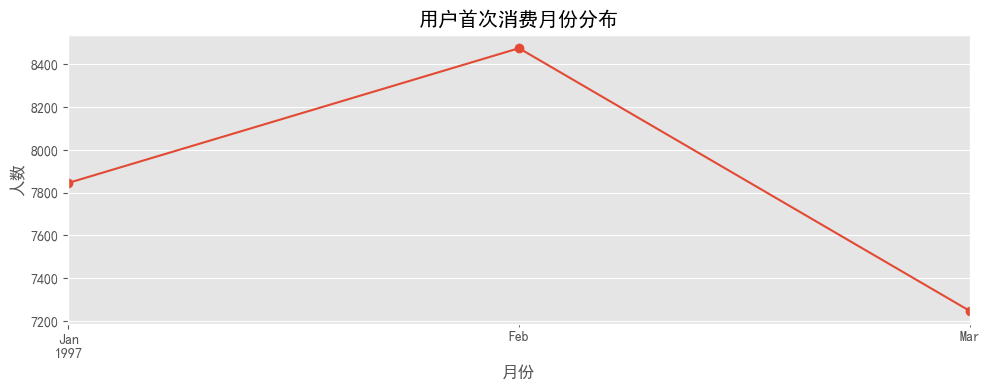

In [121]:
# 223428010210 陈梓欣
# 获取每个用户的首次消费时间
first_purchase = df.groupby('user_id')['order_dt'].min()
# 转换为月份周期格式
first_purchase_month = first_purchase.dt.to_period('M').value_counts().sort_index()

# 绘图
first_purchase_month.plot(title='用户首次消费月份分布', marker='o', figsize=(10, 4))
plt.xlabel('月份')
plt.ylabel('人数')
plt.tight_layout()
plt.show()

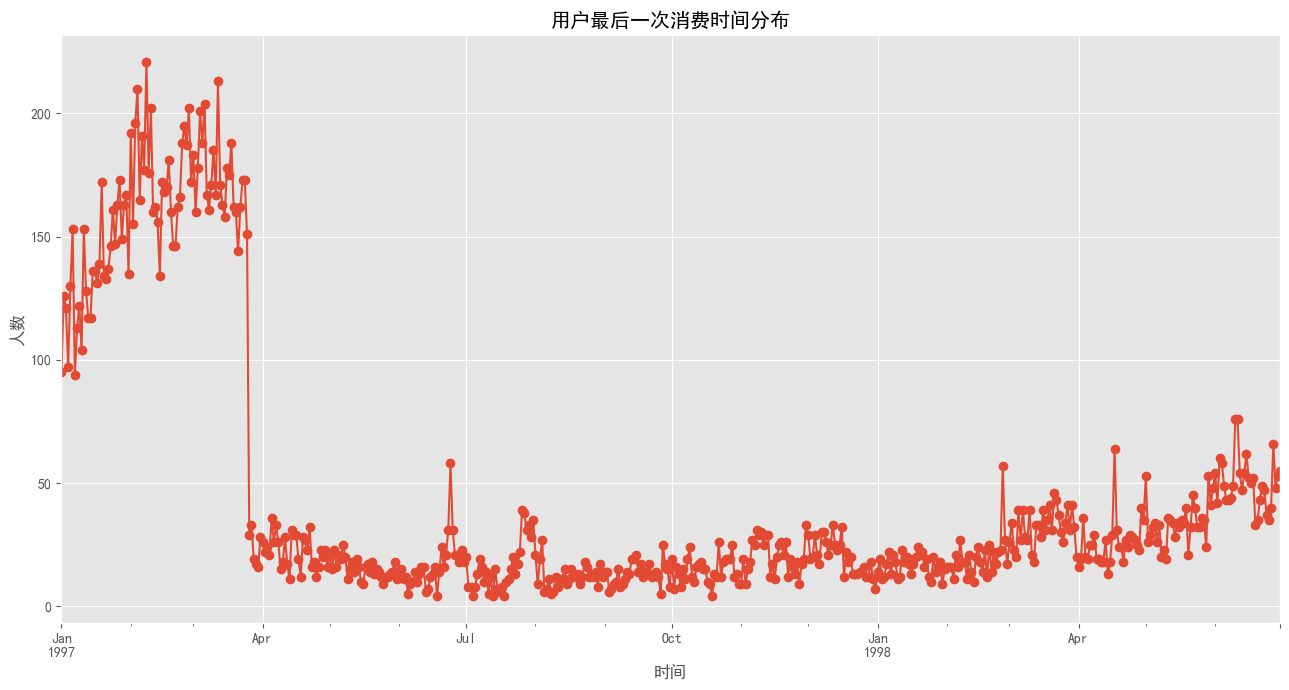

In [244]:
# 223428010210 陈梓欣
# 用户最后一次消费的时间分布
last_purchase = df.groupby('user_id')['order_dt'].max().value_counts().sort_index()

last_purchase.plot(title='用户最后一次消费时间分布', marker='o', figsize=(13, 7))
plt.xlabel('时间')
plt.ylabel('人数')
plt.grid(True)
plt.tight_layout()
plt.show()

In [142]:
# 223428010210 陈梓欣
# 消费次数
user_order_count = df.groupby('user_id').size()

# 消费一次为新用户，多次为老用户
is_new_user = user_order_count == 1
new_ratio = is_new_user.sum() / len(user_order_count)

print(f"新用户比例: {new_ratio:.2%}")
print(f"老用户比例: {(1 - new_ratio):.2%}")


新用户比例: 50.52%
老用户比例: 49.48%


In [169]:
# 223428010210 陈梓欣
rfm=df.pivot_table(['order_dt','order_products','order_amount'],index='user_id',
               aggfunc={'order_dt':'max','order_products':'count','order_amount':'sum'})

In [170]:
# 223428010210 陈梓欣
rfm['time']=(rfm['order_dt'].max()-rfm['order_dt'])/ np.timedelta64(1, 'D')
print(rfm)

         order_amount   order_dt  order_products   time
user_id                                                
1               11.77 1997-01-01               1  545.0
2               89.00 1997-01-12               2  534.0
3              156.46 1998-05-28               6   33.0
4              100.50 1997-12-12               4  200.0
5              385.61 1998-01-03              11  178.0
...               ...        ...             ...    ...
23566           36.00 1997-03-25               1  462.0
23567           20.97 1997-03-25               1  462.0
23568          121.70 1997-04-22               3  434.0
23569           25.74 1997-03-25               1  462.0
23570           94.08 1997-03-26               2  461.0

[23570 rows x 4 columns]


In [171]:
# 223428010210 陈梓欣
rfm['time']=(rfm['order_dt'].max()-rfm['order_dt'])/ np.timedelta64(1, 'D')
print(rfm.head())

         order_amount   order_dt  order_products   time
user_id                                                
1               11.77 1997-01-01               1  545.0
2               89.00 1997-01-12               2  534.0
3              156.46 1998-05-28               6   33.0
4              100.50 1997-12-12               4  200.0
5              385.61 1998-01-03              11  178.0


In [172]:
# 223428010210 陈梓欣
# 比较每一项和均值的大小，分出高低（实际工作中RFM的划分标准应该以业务为准）
rfm['r_m']=rfm['time']-rfm['time'].mean()
rfm['f_m']=rfm['order_products']-rfm['order_products'].mean()
rfm['m_m']=rfm['order_amount']-rfm['order_amount'].mean()

def hanshu(x):
    if x>0:
        return 1
    else:
        return 0

rfm['r']=rfm['r_m'].apply(hanshu)
rfm['f']=rfm['f_m'].apply(hanshu)
rfm['m']=rfm['m_m'].apply(hanshu)

print(rfm)

         order_amount   order_dt  order_products   time         r_m       f_m  \
user_id                                                                         
1               11.77 1997-01-01               1  545.0  177.778362 -1.955409   
2               89.00 1997-01-12               2  534.0  166.778362 -0.955409   
3              156.46 1998-05-28               6   33.0 -334.221638  3.044591   
4              100.50 1997-12-12               4  200.0 -167.221638  1.044591   
5              385.61 1998-01-03              11  178.0 -189.221638  8.044591   
...               ...        ...             ...    ...         ...       ...   
23566           36.00 1997-03-25               1  462.0   94.778362 -1.955409   
23567           20.97 1997-03-25               1  462.0   94.778362 -1.955409   
23568          121.70 1997-04-22               3  434.0   66.778362  0.044591   
23569           25.74 1997-03-25               1  462.0   94.778362 -1.955409   
23570           94.08 1997-0

In [173]:
# 223428010210 陈梓欣
# 比较每一项和均值的大小，分出高低（实际工作中RFM的划分标准应该以业务为准）
rfm['r_m']=rfm['time']-rfm['time'].mean()
rfm['f_m']=rfm['order_products']-rfm['order_products'].mean()
rfm['m_m']=rfm['order_amount']-rfm['order_amount'].mean()

def hanshu(x):
    if x>0:
        return 1
    else:
        return 0

rfm['r']=rfm['r_m'].apply(hanshu)
rfm['f']=rfm['f_m'].apply(hanshu)
rfm['m']=rfm['m_m'].apply(hanshu)

print(rfm.head())

         order_amount   order_dt  order_products   time         r_m       f_m  \
user_id                                                                         
1               11.77 1997-01-01               1  545.0  177.778362 -1.955409   
2               89.00 1997-01-12               2  534.0  166.778362 -0.955409   
3              156.46 1998-05-28               6   33.0 -334.221638  3.044591   
4              100.50 1997-12-12               4  200.0 -167.221638  1.044591   
5              385.61 1998-01-03              11  178.0 -189.221638  8.044591   

                m_m  r  f  m  
user_id                       
1        -94.310426  1  0  0  
2        -17.080426  1  0  0  
3         50.379574  0  1  1  
4         -5.580426  0  1  0  
5        279.529574  0  1  1  


In [174]:
# 223428010210 陈梓欣
rfm['jieguo']=rfm['r'].map(str)+rfm['f'].map(str)+rfm['m'].map(str)

ppp={'111':'重要价值客户',
     '011':'重要保持客户',
     '101':'重要发展客户',
     '001':'重要挽留客户',
     '110':'一般价值客户',
     '010':'一般保持客户',
     '100':'一般发展客户',
     '000':'一般挽留客户'}

rfm['leixing']=rfm['jieguo'].map(ppp)
print(rfm.head())

         order_amount   order_dt  order_products   time         r_m       f_m  \
user_id                                                                         
1               11.77 1997-01-01               1  545.0  177.778362 -1.955409   
2               89.00 1997-01-12               2  534.0  166.778362 -0.955409   
3              156.46 1998-05-28               6   33.0 -334.221638  3.044591   
4              100.50 1997-12-12               4  200.0 -167.221638  1.044591   
5              385.61 1998-01-03              11  178.0 -189.221638  8.044591   

                m_m  r  f  m jieguo leixing  
user_id                                      
1        -94.310426  1  0  0    100  一般发展客户  
2        -17.080426  1  0  0    100  一般发展客户  
3         50.379574  0  1  1    011  重要保持客户  
4         -5.580426  0  1  0    010  一般保持客户  
5        279.529574  0  1  1    011  重要保持客户  


In [175]:
# 223428010210 陈梓欣
# 统计不同类型客户的总消费金额、消费次数
asd = rfm.pivot_table(values=['order_amount', 'order_products'], index='leixing', aggfunc='sum')
print(asd)

         order_amount  order_products
leixing                              
一般价值客户       36200.21            1782
一般保持客户      141127.20            7371
一般发展客户      409272.88           15589
一般挽留客户       75781.48            3064
重要价值客户      103260.14            1950
重要保持客户     1591666.47           38490
重要发展客户       96849.09             877
重要挽留客户       46158.16             536


In [176]:
# 223428010210 陈梓欣
#统计各类用户的人数
print(rfm['leixing'].value_counts())

leixing
一般发展客户    13608
重要保持客户     4617
一般保持客户     1974
一般挽留客户     1532
重要发展客户      579
一般价值客户      543
重要价值客户      449
重要挽留客户      268
Name: count, dtype: int64


In [177]:
# 223428010210 陈梓欣
import numpy as np

now = df['order_dt'].max()  # 当前分析时点

# RFM表格
rfm = df.groupby('user_id').agg({
    'order_dt': lambda x: (now - x.max()) / np.timedelta64(1, 'D'),  # R
    'order_products': 'sum',  # F
    'order_amount': 'sum'     # M
}).rename(columns={'order_dt': 'R', 'order_products': 'F', 'order_amount': 'M'})

# 分层函数：按 R/F/M 分成高/低（可选3分、5分制）
def rfm_level(x, col, quantiles):
    if x[col] <= quantiles[col][0.25]:
        return '高'
    elif x[col] <= quantiles[col][0.75]:
        return '中'
    else:
        return '低'

# 分层标签
quantiles = rfm.quantile([0.25, 0.75]).to_dict()

rfm['R_等级'] = rfm.apply(rfm_level, axis=1, args=('R', quantiles))
rfm['F_等级'] = rfm.apply(rfm_level, axis=1, args=('F', quantiles))
rfm['M_等级'] = rfm.apply(rfm_level, axis=1, args=('M', quantiles))

# 用户分群规则示例（可自定义）
def rfm_segment(row):
    if row['R_等级'] == '低' and row['F_等级'] == '高' and row['M_等级'] == '高':
        return '重要价值客户'
    elif row['R_等级'] == '中' and row['F_等级'] == '高':
        return '重要保持客户'
    elif row['R_等级'] == '高' and row['F_等级'] == '高':
        return '重要挽留客户'
    elif row['R_等级'] == '低' and row['F_等级'] == '低':
        return '一般价值客户'
    else:
        return '一般发展客户'

rfm['客户类型'] = rfm.apply(rfm_segment, axis=1)

print(rfm[['R', 'F', 'M', '客户类型']].head())


             R   F       M    客户类型
user_id                           
1        545.0   1   11.77  重要价值客户
2        534.0   6   89.00  一般发展客户
3         33.0  16  156.46  一般发展客户
4        200.0   7  100.50  一般发展客户
5        178.0  29  385.61  一般发展客户


In [189]:
# 223428010210 陈梓欣
# 统计每个用户每月的消费次数（即订单数）
user_month_order_count = df.groupby(['user_id', 'month']).size().unstack(fill_value=0)
print(user_month_order_count)

month    1997-01-01  1997-02-01  1997-03-01  1997-04-01  1997-05-01  \
user_id                                                               
1                 1           0           0           0           0   
2                 2           0           0           0           0   
3                 1           0           1           1           0   
4                 2           0           0           0           0   
5                 2           1           0           1           1   
...             ...         ...         ...         ...         ...   
23566             0           0           1           0           0   
23567             0           0           1           0           0   
23568             0           0           1           2           0   
23569             0           0           1           0           0   
23570             0           0           2           0           0   

month    1997-06-01  1997-07-01  1997-08-01  1997-09-01  1997-10-01  \
user_

In [192]:
# 223428010210 陈梓欣
# 是否消费：有消费记为1，无消费记为0
user_month_has_purchase = (user_month_order_count > 0).astype(int)
print(user_month_has_purchase)

month    1997-01-01  1997-02-01  1997-03-01  1997-04-01  1997-05-01  \
user_id                                                               
1                 1           0           0           0           0   
2                 1           0           0           0           0   
3                 1           0           1           1           0   
4                 1           0           0           0           0   
5                 1           1           0           1           1   
...             ...         ...         ...         ...         ...   
23566             0           0           1           0           0   
23567             0           0           1           0           0   
23568             0           0           1           1           0   
23569             0           0           1           0           0   
23570             0           0           1           0           0   

month    1997-06-01  1997-07-01  1997-08-01  1997-09-01  1997-10-01  \
user_

In [184]:
# 223428010210 陈梓欣
def active_status(data):
    status = []
    for i in range(18):  # 数据一共有18个月份
        if data.iloc[i] == 0:
            if len(status) > 0:
                if status[i - 1] == 'unreg':
                    status.append('unreg')
                else:
                    status.append('unactive')
            else:
                status.append('unreg')
        else:
            if len(status) > 0:
                if status[i - 1] == 'unactive':
                    status.append('return')
                elif status[i - 1] == 'unreg':
                    status.append('new')
                else:
                    status.append('active')
            else:
                status.append('new')
    return pd.Series(status)

sdff=dff.apply(active_status,axis=1)
print(sdff.head())

            0         1         2         3         4         5         6   \
user_id                                                                      
1          new  unactive  unactive  unactive  unactive  unactive  unactive   
2        unreg     unreg     unreg     unreg     unreg     unreg     unreg   
3        unreg       new  unactive  unactive  unactive  unactive  unactive   
4          new  unactive  unactive  unactive  unactive  unactive  unactive   
5          new  unactive  unactive  unactive  unactive  unactive  unactive   

               7         8         9         10        11        12        13  \
user_id                                                                         
1        unactive  unactive  unactive  unactive  unactive  unactive  unactive   
2           unreg     unreg     unreg     unreg       new  unactive  unactive   
3        unactive  unactive  unactive  unactive  unactive  unactive  unactive   
4        unactive  unactive  unactive  unactive 

In [194]:
# 223428010210 陈梓欣
def active_status_v2(row):
    status = []
    purchase_list = list(row)
    first_buy_index = -1

    for i in range(len(purchase_list)):
        val = purchase_list[i]

        # 第一次消费
        if val > 0 and first_buy_index == -1:
            first_buy_index = i
            status.append('new')
        elif first_buy_index == -1:
            # 还未开始消费
            status.append('unreg')
        elif val == 0:
            # 已经开始消费了，现在没买
            if 'new' in status or 'active' in status or 'return' in status:
                status.append('unactive')
            else:
                status.append('unreg')  # 前两月没买且第3月才买，前面是 unreg
        else:
            # 当前有消费
            if status[-1] == 'unactive':
                status.append('return')
            elif status[-1] in ['new', 'active', 'return']:
                status.append('active')
            else:
                status.append('active')  # 兜底逻辑

    # 处理“前两月没买，第三月首次购买” => 把前两个标记为 unreg
    if 'new' in status:
        new_index = status.index('new')
        if new_index >= 2:
            status[0] = 'unreg'
            status[1] = 'unreg'

    return pd.Series(status)

sdff=dff.apply(active_status,axis=1)
print(sdff)

            0         1         2         3         4         5         6   \
user_id                                                                      
1          new  unactive  unactive  unactive  unactive  unactive  unactive   
2        unreg     unreg     unreg     unreg     unreg     unreg     unreg   
3        unreg       new  unactive  unactive  unactive  unactive  unactive   
4          new  unactive  unactive  unactive  unactive  unactive  unactive   
5          new  unactive  unactive  unactive  unactive  unactive  unactive   
...        ...       ...       ...       ...       ...       ...       ...   
23566    unreg     unreg     unreg     unreg     unreg     unreg     unreg   
23567    unreg     unreg     unreg     unreg     unreg     unreg     unreg   
23568    unreg     unreg     unreg     unreg     unreg     unreg     unreg   
23569    unreg     unreg     unreg     unreg     unreg     unreg     unreg   
23570    unreg     unreg     unreg     unreg     unreg     unreg

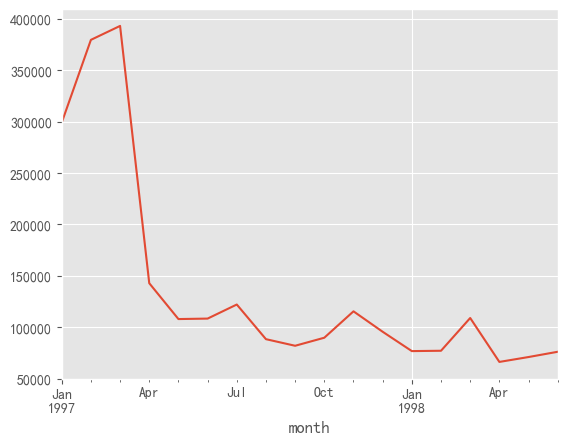

In [214]:
# 每月的总销售额
ze=df['order_amount'].groupby(df['month']).sum()
#绘制折线图
import matplotlib.pyplot as plt   #加载可视化包
plt.style.use('ggplot')    #更改设计风格

ze.plot()
plt.show()

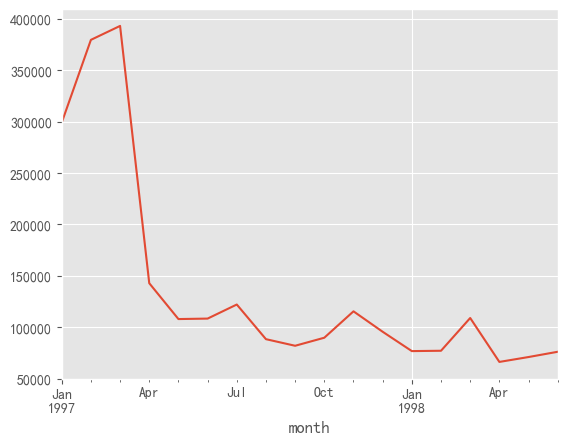

In [215]:
# 每月的产品购买量
xl=df['order_amount'].groupby(df['month']).sum()
xl.plot()
plt.show()

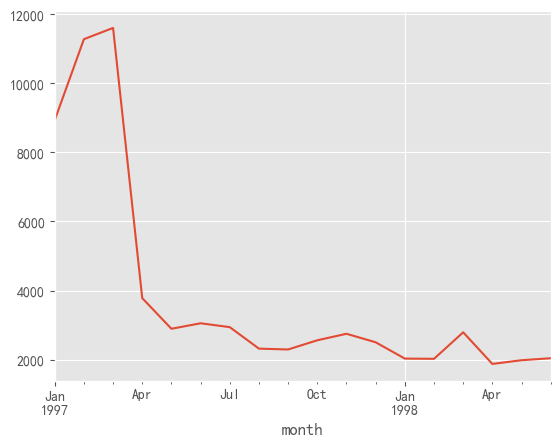

In [216]:
# 每月的消费总次数
cs=df['order_dt'].groupby(df['month']).count()
cs.plot()
plt.show()

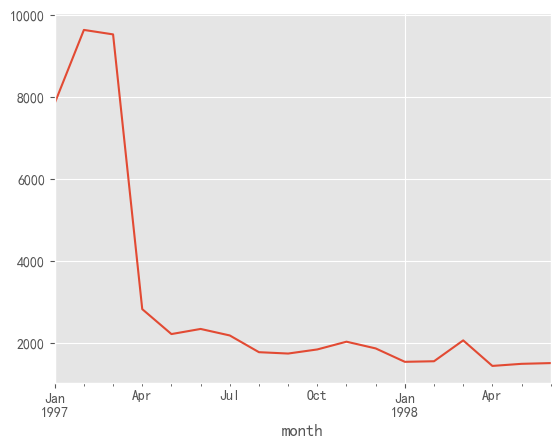

In [217]:
# 每月的消费人数
rs=df['user_id'].groupby(df['month']).apply(lambda x:len(x.unique()))
rs.plot()
plt.show()

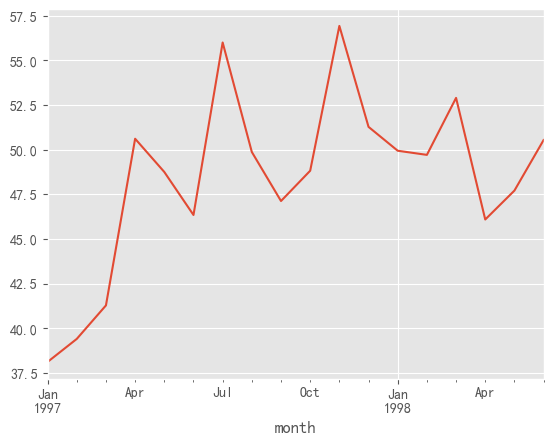

In [218]:
# 每月用户平均消费金额
zee=ze/rs
zee.plot()
plt.show()

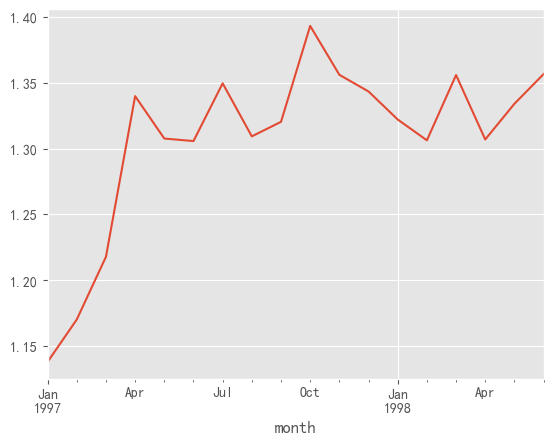

In [219]:
# 每月用户平均消费次数
css=cs/rs
css.plot()
plt.show()

In [222]:
# 223428010210 陈梓欣
# 消费总金额和消费总次数的统计描述
mg = df.groupby('user_id')[['order_amount', 'order_products']].sum()

print(mg.describe())

       order_amount  order_products
count  23570.000000    23570.000000
mean     106.080426        7.122656
std      240.925195       16.983531
min        0.000000        1.000000
25%       19.970000        1.000000
50%       43.395000        3.000000
75%      106.475000        7.000000
max    13990.930000     1033.000000


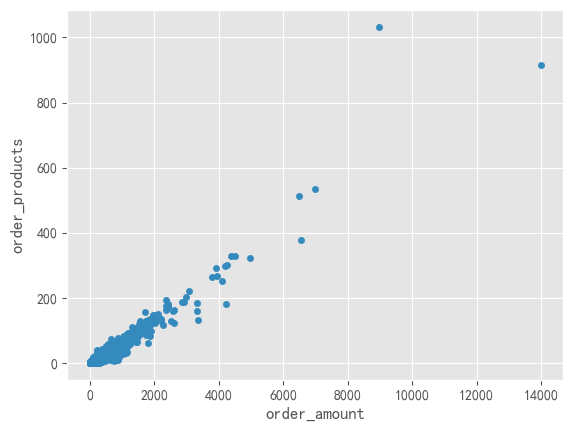

In [224]:
# 223428010103 刘渤
# 消费金额和消费产品数量的散点图
mg.plot.scatter(x='order_amount',y='order_products')
plt.show()

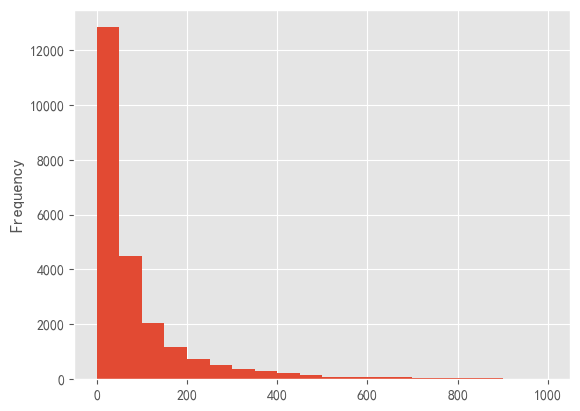

In [233]:
# 223428010103 刘渤
# 消费总金额的直方分布图(消费金额在1000之内的分布) 
mg = user_group[user_group['order_amount'] <= 1000]
mg.order_amount.plot.hist(bins=20)
plt.show()

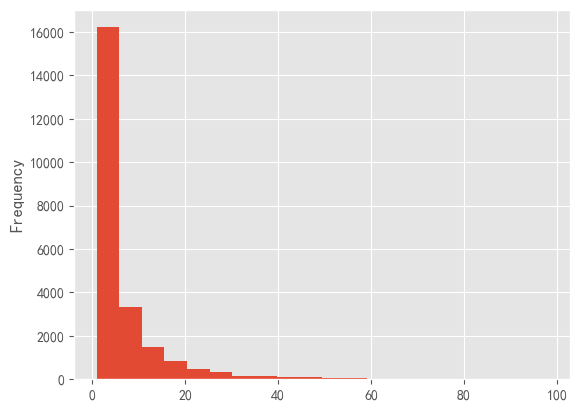

In [237]:
# 223428010103 刘渤
# 消费的总数量的直方分布图(消费商品的数量在100次之内的分布)
mg = user_group[user_group['order_products'] <= 100]
mg.order_products.plot.hist(bins=20)
plt.show()

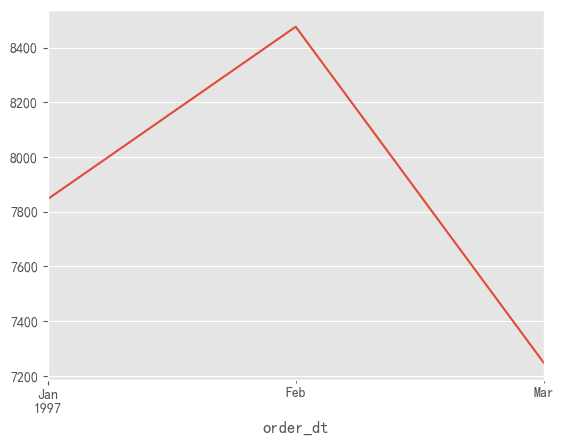

In [239]:
# 223428010103 刘渤
# 获取每个用户的首次消费月份
df['order_dt'].groupby(df['user_id']).min().dt.to_period('M').value_counts().sort_index().plot()
plt.show()

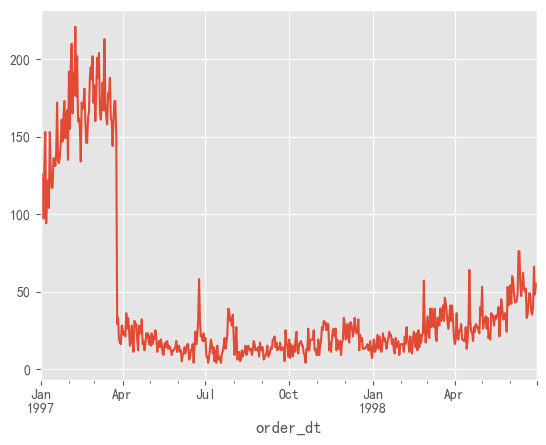

In [240]:
# 223428010103 刘渤
# 用户最后一次消费的时间分布
df['order_dt'].groupby(df['user_id']).max().value_counts().sort_index().plot()
plt.show()

In [246]:
# 223428010103 刘渤
# 每个用户的消费次数（即订单数）
user_order_count = df.groupby('user_id').size()

# 判断新老客户：消费1次为新客户，否则为老客户
user_type = user_order_count.apply(lambda x: '新客户' if x == 1 else '老客户')

# 统计新老客户数量和比例
customer_type_stats = user_type.value_counts()
customer_type_ratio = customer_type_stats / customer_type_stats.sum()
print("\n新老客户占比：\n", customer_type_ratio)



新老客户占比：
 新客户    0.505218
老客户    0.494782
Name: count, dtype: float64


In [247]:
# 223428010103 刘渤
# 统计每个用户每月的消费次数（即订单数）
user_month_order_count = df.groupby(['user_id', 'month']).size().unstack(fill_value=0)
print(user_month_order_count.head())

month    1997-01-01  1997-02-01  1997-03-01  1997-04-01  1997-05-01  \
user_id                                                               
1                 1           0           0           0           0   
2                 2           0           0           0           0   
3                 1           0           1           1           0   
4                 2           0           0           0           0   
5                 2           1           0           1           1   

month    1997-06-01  1997-07-01  1997-08-01  1997-09-01  1997-10-01  \
user_id                                                               
1                 0           0           0           0           0   
2                 0           0           0           0           0   
3                 0           0           0           0           0   
4                 0           0           1           0           0   
5                 1           1           0           1           0   

mont

In [249]:
# 223428010103 刘渤
dff=df.pivot_table(['order_dt'],index='user_id',columns='month',aggfunc='count')
dff.fillna(0,inplace=True)
print(dff.head())

          order_dt                                                         \
month   1997-01-01 1997-02-01 1997-03-01 1997-04-01 1997-05-01 1997-06-01   
user_id                                                                     
1              1.0        0.0        0.0        0.0        0.0        0.0   
2              2.0        0.0        0.0        0.0        0.0        0.0   
3              1.0        0.0        1.0        1.0        0.0        0.0   
4              2.0        0.0        0.0        0.0        0.0        0.0   
5              2.0        1.0        0.0        1.0        1.0        1.0   

                                                                           \
month   1997-07-01 1997-08-01 1997-09-01 1997-10-01 1997-11-01 1997-12-01   
user_id                                                                     
1              0.0        0.0        0.0        0.0        0.0        0.0   
2              0.0        0.0        0.0        0.0        0.0        0.0  

In [250]:
# 223428010103 刘渤
# 是否消费：有消费记为1，无消费记为0
dff_purchase = (dff > 0).astype(int)
print(dff_purchase.head())

          order_dt                                                         \
month   1997-01-01 1997-02-01 1997-03-01 1997-04-01 1997-05-01 1997-06-01   
user_id                                                                     
1                1          0          0          0          0          0   
2                1          0          0          0          0          0   
3                1          0          1          1          0          0   
4                1          0          0          0          0          0   
5                1          1          0          1          1          1   

                                                                           \
month   1997-07-01 1997-08-01 1997-09-01 1997-10-01 1997-11-01 1997-12-01   
user_id                                                                     
1                0          0          0          0          0          0   
2                0          0          0          0          0          0  

In [253]:
# 223428010103 刘渤
def active_status(data):
    status = []
    purchase_list = list(data)
    first_buy_index = -1

    for i in range(len(purchase_list)):
        val = purchase_list[i]

        # 第一次消费
        if val > 0 and first_buy_index == -1:
            first_buy_index = i
            status.append('new')
        elif first_buy_index == -1:
            # 还未开始消费
            status.append('unreg')
        elif val == 0:
            # 已经开始消费了，现在没买
            if 'new' in status or 'active' in status or 'return' in status:
                status.append('unactive')
            else:
                status.append('unreg')  # 前两月没买且第3月才买，前面是 unreg
        else:
            # 当前有消费
            if status[-1] == 'unactive':
                status.append('return')
            elif status[-1] in ['new', 'active', 'return']:
                status.append('active')
            else:
                status.append('active')  # 兜底逻辑

    # 处理“前两月没买，第三月首次购买” => 把前两个标记为 unreg
    if 'new' in status:
        new_index = status.index('new')
        if new_index >= 2:
            status[0] = 'unreg'
            status[1] = 'unreg'

    return pd.Series(status)

sdff=dff.apply(active_status,axis=1)
print(sdff.head())

          0         1         2         3         4         5         6   \
user_id                                                                    
1        new  unactive  unactive  unactive  unactive  unactive  unactive   
2        new  unactive  unactive  unactive  unactive  unactive  unactive   
3        new  unactive    return    active  unactive  unactive  unactive   
4        new  unactive  unactive  unactive  unactive  unactive  unactive   
5        new    active  unactive    return    active    active    active   

               7         8         9         10        11        12        13  \
user_id                                                                         
1        unactive  unactive  unactive  unactive  unactive  unactive  unactive   
2        unactive  unactive  unactive  unactive  unactive  unactive  unactive   
3        unactive  unactive  unactive    return  unactive  unactive  unactive   
4          return  unactive  unactive  unactive    return  una